# import important libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error
import plotly.graph_objects as go


In [34]:
df = pd.read_csv('../data/Google_historical_data.csv')
df.head()

,Date,Open,High,Low,Close,Volume,ticker,name
0,2004-08-19 00:00:00-04:00,2.483736,2.584576,2.383393,2.492181,893181924,GOOGL,Alphabet Inc. (GOOGL) Historical Data
1,2004-08-20 00:00:00-04:00,2.508822,2.709260,2.496155,2.690134,456686856,GOOGL,Alphabet Inc. (GOOGL) Historical Data
2,2004-08-23 00:00:00-04:00,2.750738,2.818544,2.708514,2.717207,365122512,GOOGL,Alphabet Inc. (GOOGL) Historical Data
3,2004-08-24 00:00:00-04:00,2.762908,2.771850,2.572406,2.604694,304946748,GOOGL,Alphabet Inc. (GOOGL) Historical Data
4,2004-08-25 00:00:00-04:00,2.606930,2.682435,2.580105,2.632761,183772044,GOOGL,Alphabet Inc. (GOOGL) Historical Data


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5373 entries, 0 to 5372
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5373 non-null   object 
 1   Open    5373 non-null   float64
 2   High    5373 non-null   float64
 3   Low     5373 non-null   float64
 4   Close   5373 non-null   float64
 5   Volume  5373 non-null   int64  
 6   ticker  5373 non-null   object 
 7   name    5373 non-null   object 
dtypes: float64(4), int64(1), object(3)
memory usage: 335.9+ KB


In [36]:
df.describe().T\
    .style.background_gradient(cmap='viridis')\
    .set_table_styles([{
        'selector': 'th', 
        'props': [('font-size', '12pt')]
        }]).\
        set_caption("Statistical Summary of Google Stock Data")

,count,mean,std,min,25%,50%,75%,max
Open,5373.000000,54.925057,57.011319,2.463617,13.293948,29.312309,75.112966,325.996755
High,5373.000000,55.520014,57.675052,2.526953,13.398762,29.501594,75.883636,328.615037
Low,5373.000000,54.337891,56.361989,2.383393,13.154611,29.114519,74.571555,318.961364
Close,5373.000000,54.943370,57.037104,2.483985,13.278549,29.317486,75.243484,323.228577
Volume,5373.000000,111987702.429927,144523119.643200,9312000.000000,30290000.000000,52670200.000000,132303564.000000,1643023332.000000


In [37]:
df['Date'] = pd.to_datetime(df['Date'], utc=True)
df['Date'] = df['Date'].dt.tz_convert(None)
df.set_index('Date', inplace=True)

In [38]:
import plotly.graph_objects as go
# Price data
price = df['Close']

# Color logic: green if price goes up, red if goes down
colors = np.where(price.diff() >= 0, 'green', 'red')

fig = go.Figure()

# Plot segment-wise (real market style)
for i in range(1, len(df)):
    fig.add_trace(go.Scatter(
        x=df.index[i-1:i+1],
        y=price[i-1:i+1],
        mode='lines',
        line=dict(color=colors[i], width=2),
        showlegend=False
    ))

# Layout styling
fig.update_layout(
    title="Google Stock Closing Price Over Time",
    xaxis_title="Year",
    yaxis_title="Price (USD)",
    template="plotly_white",
    dragmode="zoom"
)

fig.show()


In [39]:
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()


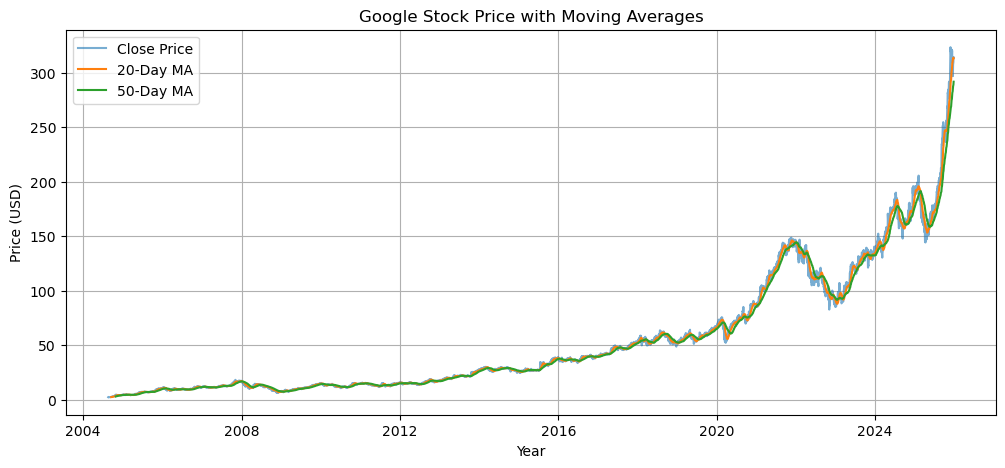

In [40]:
plt.figure(figsize=(12,5))
plt.plot(df['Close'], label='Close Price', alpha=0.6)
plt.plot(df['MA_20'], label='20-Day MA')
plt.plot(df['MA_50'], label='50-Day MA')
plt.title("Google Stock Price with Moving Averages")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid(True)
plt.show()


In [41]:

features = df[['Close', 'MA_20', 'MA_50']].dropna()
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)


In [42]:
close_prices = df[['Close']].values

scaler = MinMaxScaler(feature_range=(0,1))
scaled_close = scaler.fit_transform(close_prices)

In [43]:
def create_sequences(data, window_size=60):
    X, y = [], []
    for i in range(window_size, len(data)):
        X.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_close, window_size=60)


In [44]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [45]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()


/home/mrityunjay/anaconda3/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 60, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 4.7191e-04 - val_loss: 7.6798e-04
Epoch 2/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 3.0185e-05 - val_loss: 8.0789e-04
Epoch 3/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 2.4685e-05 - val_loss: 7.5243e-04
Epoch 4/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 2.3354e-05 - val_loss: 7.1879e-04
Epoch 5/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 2.2191e-05 - val_loss: 7.0983e-04
Epoch 6/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 2.0924e-05 - val_loss: 5.2581e-04
Epoch 7/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 2.6937e-05 - val_loss: 6.8655e-04
Epoch 8/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 2.1473e-05 - val_loss: 4.8157e-04
Epoch 9/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 2.2594e-05 - val_loss: 4.2041e-04
Epoch 10/10
133/133 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 2.0187e-05 - val_loss: 4.9657e-04


In [47]:
predicted_scaled = model.predict(X_test)


34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step


In [48]:
actual = scaler.inverse_transform(actual.reshape(-1,1)).flatten()
predicted = scaler.inverse_transform(predicted.reshape(-1,1)).flatten()


In [ ]:
fig = go.Figure()

# Actual prices
fig.add_trace(go.Scatter(
    y=actual,
    mode='lines',
    name='Actual Price',
    line=dict(color='green', width=2)
))

# Predicted prices
fig.add_trace(go.Scatter(
    y=predicted,
    mode='lines',
    name='Predicted Price',
    line=dict(color='red', width=2, dash='dash')
))

fig.update_layout(
    title="LSTM Stock Price Prediction",
    xaxis_title="Days",
    yaxis_title="Price (USD)",
    hovermode="x unified",
    template="plotly_white",
    dragmode="zoom"
)

fig.show()


In [50]:
mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))

print("LSTM MAE:", mae)
print("LSTM RMSE:", rmse)

LSTM MAE: 432912.4773840164
LSTM RMSE: 590098.6191459617
